In [10]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [20]:
import sys
import os
import torch
import copy
from torch.utils.data import DataLoader, Subset
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict
from tqdm import tqdm

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

In [12]:
from src.trainer import SimpleTrainer, FisherTrainer, IntervalTrainer
from src.data_utils import (
    get_mnist_tasks,
    _extract_targets,
    get_context_sets,
    create_holdout_set,
)
from src.utils import InContextHead
from src import models
from src.buffer import MultiTaskBuffer
from src.interval_utils import create_violation_mask

In [13]:
train_tasks, val_tasks, test_tasks = get_mnist_tasks()

model = models.get_mnist_model()
model.to("mps")
model.train()

print(
    f"Tasks: {[torch._unique(_extract_targets(train))[0].tolist() for train in train_tasks]}"
)

Tasks: [[3, 4], [8, 9], [6, 7], [0, 5], [1, 2]]


In [14]:
train_tasks, buffer_sets = zip(
    *[create_holdout_set(dataset) for dataset in train_tasks]
)
print([len(task) for task in buffer_sets])

[3837, 3839, 3838, 3839, 3844]


In [27]:
trainer = SimpleTrainer(model)
trainer.train(train_tasks[0], val_tasks[0], epochs=3, batch_size=256)
trainer.test(test_tasks[0:2])

Training Epochs: 100%|██████████| 3/3 [00:05<00:00,  1.97s/it, val_loss=0.0131, val_acc=0.996]


Test Results: [(0.0142, 0.9955), (38.3244, 0.0)]


[(0.0142, 0.9955), (38.3244, 0.0)]

In [28]:
save_model = copy.deepcopy(trainer.model)

In [29]:
interval_trainer = IntervalTrainer(
    save_model,
    checkpoint=200,
    n_iters=200,
    min_acc_limit=0.8,
    min_acc_increment=0,
    primal_learning_rate=0.5,
    paradigm="CIL",
    seed=0
)

# Compute bounds for task 0
interval_trainer.compute_rashomon_set(test_tasks[0])

# Train task 1 until plateau
interval_trainer.train(train_tasks[1], val_tasks[1], batch_size=256, epochs=3)
interval_trainer.test(test_tasks[0:2])

---------------------------- Computing Rashomon set ----------------------------
Initial acc constraint violation: -0.1961 (Positive = violated)
Number of model parameters: 6179
Computing Rashomon set with min acc limit: 0.80
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=1.00,  Min acc soft=1.00


100%|██████████| 200/200 [00:22<00:00,  8.87it/s, size=1745.50, obj=0.281, min_soft_acc=0.782]


Final bbox:  Obj=0.28,  Size=1745.50,  Min acc hard=0.79,  Min acc soft=0.79
Computing final certificates over 256 samples
Checkpointed every 200 iterations for a total of 1 checkpoints
Checkpoints sizes: ['1745.50']
Checkpoint certificates: ['0.79']
----------------------- Finished Computing Rashomon set ------------------------


Training Epochs: 100%|██████████| 3/3 [00:08<00:00,  2.81s/it, loss=2.9249, val_acc=0.2842, proj=0]


Test Results: [(0.9429, 0.8317), (2.7683, 0.276)]


[(0.9429, 0.8317), (2.7683, 0.276)]

In [30]:
fisher_trainer = FisherTrainer(
    save_model,
    checkpoint=200,
    n_iters=200,
    min_acc_limit=0.8,
    min_acc_increment=0,
    primal_learning_rate=0.5,
    paradigm="CIL",
    seed=0
)

# Compute bounds for task 0
fisher_trainer.compute_rashomon_set(test_tasks[0], prune_prop=0)

# Train task 1 until plateau
fisher_trainer.train(train_tasks[1], val_tasks[1], batch_size=256, epochs=3)
fisher_trainer.test(test_tasks[0:2])

---------------------------- Computing Rashomon set ----------------------------
Initial acc constraint violation: -0.1961 (Positive = violated)
Number of model parameters: 6179
Computing Rashomon set with min acc limit: 0.80
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=1.00,  Min acc soft=1.00


100%|██████████| 200/200 [00:22<00:00,  8.74it/s, size=1745.50, obj=0.281, min_soft_acc=0.782]


Final bbox:  Obj=0.28,  Size=1745.50,  Min acc hard=0.79,  Min acc soft=0.79
Computing final certificates over 256 samples
Checkpointed every 200 iterations for a total of 1 checkpoints
Checkpoints sizes: ['1745.50']
Checkpoint certificates: ['0.79']
----------------------- Finished Computing Rashomon set ------------------------


Training Epochs: 100%|██████████| 3/3 [00:08<00:00,  2.80s/it, loss=2.9249, val_acc=0.2842, proj=0]


Test Results: [(0.9429, 0.8317), (2.7683, 0.276)]


[(0.9429, 0.8317), (2.7683, 0.276)]

In [ ]:
fisher_trainer = FisherTrainer(
    save_model,
    checkpoint=200,
    n_iters=200,
    min_acc_limit=0.8,
    min_acc_increment=0,
    primal_learning_rate=0.5,
    paradigm="CIL",
    seed=0
)

loader = DataLoader(
        Subset(train_tasks[1], range(64)),
        batch_size=32,
        shuffle=True,
        generator=torch.Generator().manual_seed(0),
    )

fisher_trainer._compute_fisher_diagonal(loader)

fisher_trainer.compute_rashomon_set(test_tasks[0], prune_prop=0.7)
fisher_trainer.train(train_tasks[1], val_tasks[1], epochs=3, batch_size=256)
fisher_trainer.test(test_tasks[0:2])

Test Results: [(0.0142, 0.9955), (38.3244, 0.0)]


Computing Fisher Information: 100%|██████████| 2/2 [00:00<00:00, 18.55it/s]

To keep top 30%, found global Fisher threshold: 0.5087
---------------------------- Computing Rashomon set ----------------------------


Initial acc constraint violation: -0.1961 (Positive = violated)
Number of model parameters: 6179
Computing Rashomon set with min acc limit: 0.80
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=1.00,  Min acc soft=1.00


100%|██████████| 200/200 [00:23<00:00,  8.65it/s, size=293.67, obj=0.047, min_soft_acc=0.788]


Final bbox:  Obj=0.05,  Size=293.67,  Min acc hard=0.79,  Min acc soft=0.79
Computing final certificates over 256 samples
Checkpointed every 200 iterations for a total of 1 checkpoints
Checkpoints sizes: ['293.67']
Checkpoint certificates: ['0.79']
----------------------- Finished Computing Rashomon set ------------------------
Test Results: [(0.0142, 0.9955), (38.3244, 0.0)]


Training Epochs: 100%|██████████| 3/3 [00:08<00:00,  2.82s/it, loss=0.4878, val_acc=0.8295, proj=0]


Test Results: [(0.2397, 0.9331), (0.4897, 0.8184)]


[(0.2397, 0.9331), (0.4897, 0.8184)]

In [34]:
def run_experiment(seed, require_prev=True, pruning_prop=0.7):
    train_tasks, val_tasks, test_tasks = get_mnist_tasks(seed=seed)

    model = models.get_mnist_model(seed=seed)
    model.to("mps")

    train_tasks, _ = zip(
        *[create_holdout_set(dataset) for dataset in train_tasks]
    )
    trainer = SimpleTrainer(model, seed=seed)
    trainer.train(train_tasks[0], val_tasks[0], epochs=3, batch_size=256)
    trainer.test(test_tasks[0:1])

    save_model = copy.deepcopy(trainer.model)

    interval_trainer = IntervalTrainer(
        save_model,
        checkpoint=200,
        n_iters=200,
        min_acc_limit=0.8,
        min_acc_increment=0,
        primal_learning_rate=0.5,
        paradigm="CIL",
        seed=seed
    )

    # Compute bounds for task 0
    prev = []
    if require_prev:
        interval_trainer.compute_rashomon_set(test_tasks[0])

        assert interval_trainer.test(test_tasks[0:2])[1][1] == 0, "Base model performance on second task needs to be zero."
        # Train task 1 until plateau
        interval_trainer.train(train_tasks[1], val_tasks[1], batch_size=256, epochs=3)
        print("No pruning performance: ", end='')
        prev = interval_trainer.test(test_tasks[0:2])


    fisher_trainer = FisherTrainer(
        save_model,
        checkpoint=200,
        n_iters=200,
        min_acc_limit=0.8,
        min_acc_increment=0,
        primal_learning_rate=0.5,
        paradigm="CIL",
        seed=seed
    )

    loader = DataLoader(
            Subset(train_tasks[1], range(64)),
            batch_size=64,
            shuffle=True,
            generator=torch.Generator().manual_seed(seed),
        )

    fisher_trainer._compute_fisher_diagonal(loader)

    fisher_trainer.compute_rashomon_set(test_tasks[0], prune_prop=pruning_prop)
    assert fisher_trainer.test(test_tasks[0:2])[1][1] == 0
    fisher_trainer.train(train_tasks[1], val_tasks[1], epochs=3, batch_size=256)
    new = fisher_trainer.test(test_tasks[0:2])

    return prev, new

In [38]:
prev_perf = []
new_perf = []
# reds = []
for i in range(10):
    result = run_experiment(i, pruning_prop=0.8)
    prev_perf.append(result[0])
    new_perf.append(result[1])
    # reds.append(result[2])

Training Epochs: 100%|██████████| 3/3 [00:06<00:00,  2.26s/it, val_loss=0.0171, val_acc=0.994]


Test Results: [(0.0156, 0.9935)]
---------------------------- Computing Rashomon set ----------------------------
Initial acc constraint violation: -0.1849 (Positive = violated)
Number of model parameters: 6179
Computing Rashomon set with min acc limit: 0.80
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=0.98,  Min acc soft=0.98


100%|██████████| 200/200 [00:25<00:00,  7.92it/s, size=1623.07, obj=0.261, min_soft_acc=0.789]


Final bbox:  Obj=0.26,  Size=1623.07,  Min acc hard=0.79,  Min acc soft=0.79
Computing final certificates over 256 samples
Checkpointed every 200 iterations for a total of 1 checkpoints
Checkpoints sizes: ['1623.07']
Checkpoint certificates: ['0.79']
----------------------- Finished Computing Rashomon set ------------------------
Test Results: [(0.0156, 0.9935), (64.1253, 0.0)]


Training Epochs: 100%|██████████| 3/3 [00:09<00:00,  3.15s/it, loss=1.9775, val_acc=0.5201, proj=0]


...

Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=0.97,  Min acc soft=0.97


100%|██████████| 200/200 [00:22<00:00,  8.86it/s, size=176.41, obj=0.028, min_soft_acc=0.804]


Final bbox:  Obj=0.03,  Size=176.41,  Min acc hard=0.83,  Min acc soft=0.83
Computing final certificates over 256 samples
Checkpointed every 200 iterations for a total of 1 checkpoints
Checkpoints sizes: ['176.41']
Checkpoint certificates: ['0.83']
----------------------- Finished Computing Rashomon set ------------------------
Test Results: [(0.0453, 0.9868), (42.0207, 0.0)]


Training Epochs: 100%|██████████| 3/3 [00:09<00:00,  3.07s/it, loss=0.7590, val_acc=0.7379, proj=0]


Test Results: [(0.4076, 0.8671), (0.8501, 0.7328)]


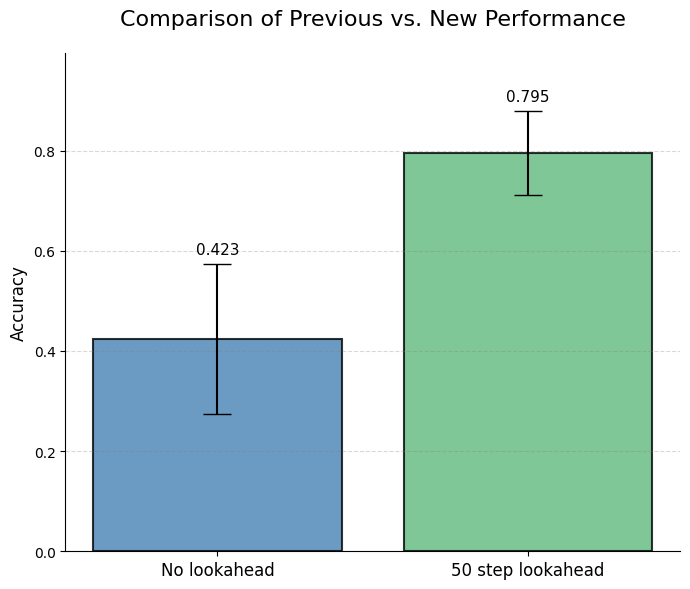

In [39]:
prev_acc = np.array([val[1][1] for val in prev_perf]).mean()
prev_std = np.array([val[1][1] for val in prev_perf]).std()
new_acc = np.array([val[1][1] for val in new_perf]).mean()
new_std = np.array([val[1][1] for val in new_perf]).std()

# 2. Create a prettier plot
# Use a more balanced figure size
fig, ax = plt.subplots(figsize=(7, 6))

# Define some nice colors
colors = ['#4682B4', '#5FBA7D'] # Steel Blue and a nice Green

# Plot the bars with improved styling
bars = ax.bar(
    x=["Previous", "New"],
    height=[prev_acc, new_acc],
    yerr=[prev_std, new_std],
    color=colors,
    alpha=0.8,                # Make bars slightly transparent
    edgecolor='black',        # Add a crisp black edge
    capsize=10,               # THIS IS KEY: Adds caps to the error bars
    ecolor='black',           # Color of the error bar lines
    linewidth=1.5
)

# 3. Add Labels, Title, and Grid for context
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparison of Previous vs. New Performance', fontsize=16, pad=20)
ax.set_xticks(ticks=[0, 1], labels=["No lookahead", "50 step lookahead"], fontsize=12)

# Add a subtle horizontal grid to make comparisons easier
ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.3)

# Remove the top and right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Set a dynamic Y-axis limit for better spacing
ax.set_ylim(0, max(new_acc, prev_acc) + max(new_std, prev_std) + 0.05)

# 4. Add data labels on top of the bars
# This shows the exact mean value on the plot
ax.bar_label(bars, fmt='{:.3f}', padding=5, fontsize=11, color='black')

# Ensure everything fits without overlapping
plt.tight_layout()
plt.show()

In [40]:
data = defaultdict(list)
pruning_prop = [0, 0.05, 0.1, 0.3, 0.5, 0.7, 0.8, 0.85]
for prop in tqdm(pruning_prop):
    for i in range(3):
        data[prop].append(run_experiment(i, pruning_prop=prop))

Training Epochs: 100%|██████████| 3/3 [00:06<00:00,  2.20s/it, val_loss=0.0171, val_acc=0.994]


Test Results: [(0.0156, 0.9935)]
---------------------------- Computing Rashomon set ----------------------------
Initial acc constraint violation: -0.1849 (Positive = violated)
Number of model parameters: 6179
Computing Rashomon set with min acc limit: 0.80
Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=0.98,  Min acc soft=0.98


100%|██████████| 200/200 [00:23<00:00,  8.48it/s, size=1623.07, obj=0.261, min_soft_acc=0.789]


Final bbox:  Obj=0.26,  Size=1623.07,  Min acc hard=0.79,  Min acc soft=0.79
Computing final certificates over 256 samples
Checkpointed every 200 iterations for a total of 1 checkpoints
Checkpoints sizes: ['1623.07']
Checkpoint certificates: ['0.79']
----------------------- Finished Computing Rashomon set ------------------------
Test Results: [(0.0156, 0.9935), (64.1253, 0.0)]


Training Epochs: 100%|██████████| 3/3 [00:09<00:00,  3.10s/it, loss=1.9775, val_acc=0.5201, proj=0]


...

Initial bbox:  Obj=0.00,  Size=0.00,  Min acc hard=1.00,  Min acc soft=1.00


100%|██████████| 200/200 [00:21<00:00,  9.11it/s, size=142.21, obj=0.023, min_soft_acc=0.817]


Final bbox:  Obj=0.02,  Size=142.21,  Min acc hard=0.80,  Min acc soft=0.80
Computing final certificates over 256 samples
Checkpointed every 200 iterations for a total of 1 checkpoints
Checkpoints sizes: ['142.21']
Checkpoint certificates: ['0.80']
----------------------- Finished Computing Rashomon set ------------------------
Test Results: [(0.0015, 0.9995), (60.3104, 0.0)]


100%|██████████| 8/8 [29:27<00:00, 220.93s/it]

Test Results: [(0.5275, 0.8652), (0.971, 0.7995)]


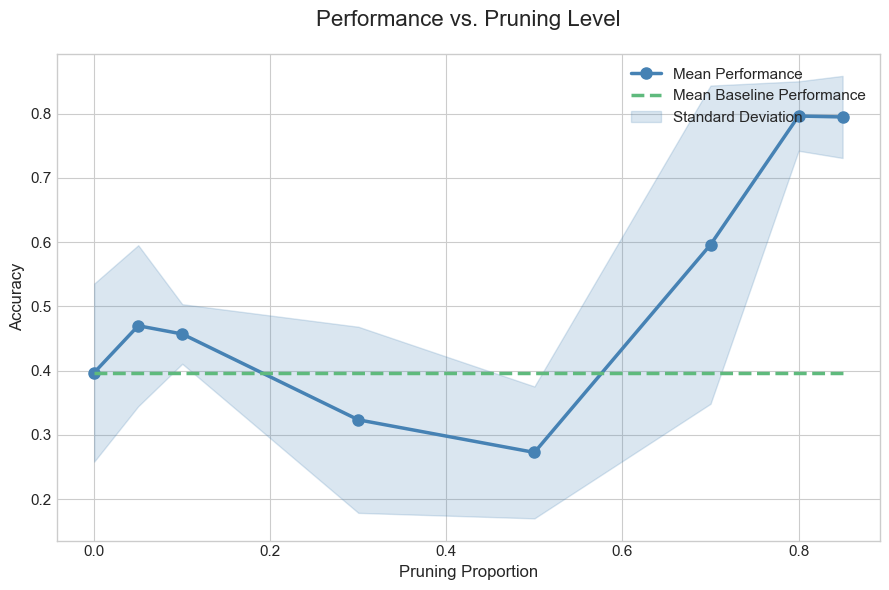

In [42]:
x_vals, y_means, y_stds = [], [], []
prev_means = []
prop_mean = []
for key, item in data.items():
    x_vals.append(key)
    # Create the numpy array once
    values = np.array([val[1][1][1] for val in item])
    y_means.append(values.mean())
    y_stds.append(values.std())
    prop_mean.append(np.array([val[0] for val in item]).mean())
    prev_means.append(np.array([val[0][1][1] for val in item]).mean())

# Convert lists to numpy arrays for easier calculations
x_vals = np.array(x_vals)
y_means = np.array(y_means)
y_stds = np.array(y_stds)

# 2. Create a prettier plot
# Use a pre-defined style for a professional look
plt.style.use('seaborn-v0_8-whitegrid')
fig, ax = plt.subplots(figsize=(9, 6))

# Define a color for the plot
primary_color, secondary_color = ['#4682B4', '#5FBA7D']

# 3. Plot the main line with markers
ax.plot(
    x_vals,
    y_means,
    color=primary_color,
    linewidth=2.5,
    marker='o',             # Add circles at each data point
    markersize=8,
    label='Mean Performance'
)

ax.plot(
    x_vals,
    prev_means,
    color=secondary_color,
    linewidth=2.5,
    markersize=8,
    linestyle="--",
    label='Mean Baseline Performance'
)

# 4. Add the shaded error band (the key improvement!)
# The alpha value makes the shade transparent
ax.fill_between(
    x_vals,
    y_means - y_stds,       # Lower bound of the error
    y_means + y_stds,       # Upper bound of the error
    color=primary_color,
    alpha=0.2,
    label='Standard Deviation'
)

# 5. Add Labels, Title, and Legend
ax.set_title('Performance vs. Pruning Level', fontsize=16, pad=20)
ax.set_xlabel('Pruning Proportion', fontsize=12)
ax.set_ylabel('Accuracy', fontsize=12)
ax.legend(loc='upper right', fontsize=11)

# Customize tick parameters
ax.tick_params(axis='both', which='major', labelsize=11)

# plt.plot(x_vals, prop_mean)

# Ensure everything fits nicely
plt.tight_layout()
plt.show()
